In [1]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 117.6 MB/s eta 0:00:00


In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths, get_results_path
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.enhancements.kga import augment_with_kga
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "kga"
inject_roles = False
role_flag = False

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [5]:
# --- Load datasets ---
paths = get_dataset_paths(enhancement)

augment_with_kga(paths["train"], output_path=paths["train"])
augment_with_kga(paths["dev"], output_path=paths["dev"])

train_dataset = COGSDataset(paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
dev_dataset   = COGSDataset(paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
test_dataset  = COGSDataset(paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)
gen_dataset   = COGSDataset(paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=inject_roles, role_flag=role_flag)

Dataset saved to: /notebooks/meta-semantic-research/data/kga/train.tsv
Dataset saved to: /notebooks/meta-semantic-research/data/kga/dev.tsv


In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

Train Loss (Epoch 1): 0.6237
Dev Eval (Epoch 1):
  exact_match: 0.0223
  precision: 0.6706
  recall: 0.6390
  f1: 0.6255
  bleu: 0.4914
  edit_distance_avg: 56.0550
  predicate_accuracy: 0.7313
  valid_logical_form_ratio: 0.9850
Train Loss (Epoch 2): 0.1729
Dev Eval (Epoch 2):
  exact_match: 0.2070
  precision: 0.8585
  recall: 0.8164
  f1: 0.8303
  bleu: 0.7090
  edit_distance_avg: 26.6627
  predicate_accuracy: 0.8802
  valid_logical_form_ratio: 0.9987
Train Loss (Epoch 3): 0.1117
Dev Eval (Epoch 3):
  exact_match: 0.3760
  precision: 0.9295
  recall: 0.9127
  f1: 0.9183
  bleu: 0.8405
  edit_distance_avg: 15.1010
  predicate_accuracy: 0.9338
  valid_logical_form_ratio: 0.9993
Train Loss (Epoch 4): 0.0784
Dev Eval (Epoch 4):
  exact_match: 0.4863
  precision: 0.9690
  recall: 0.9653
  f1: 0.9662
  bleu: 0.9032
  edit_distance_avg: 7.2260
  predicate_accuracy: 0.9629
  valid_logical_form_ratio: 1.0000
Train Loss (Epoch 5): 0.0589
Dev Eval (Epoch 5):
  exact_match: 0.5643
  precision: 0

Predictions saved to: /notebooks/meta-semantic-research/predictions/kga/t5-small_test_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/kga/t5-small_test_metrics.csv
Test Eval:
  exact_match: 0.0000
  precision: 0.9848
  recall: 0.9763
  f1: 0.9798
  bleu: 0.4928
  edit_distance_avg: 9.9777
  predicate_accuracy: 0.9744
  valid_logical_form_ratio: 1.0000


ValueError: Unknown format code 'f' for object of type 'str'

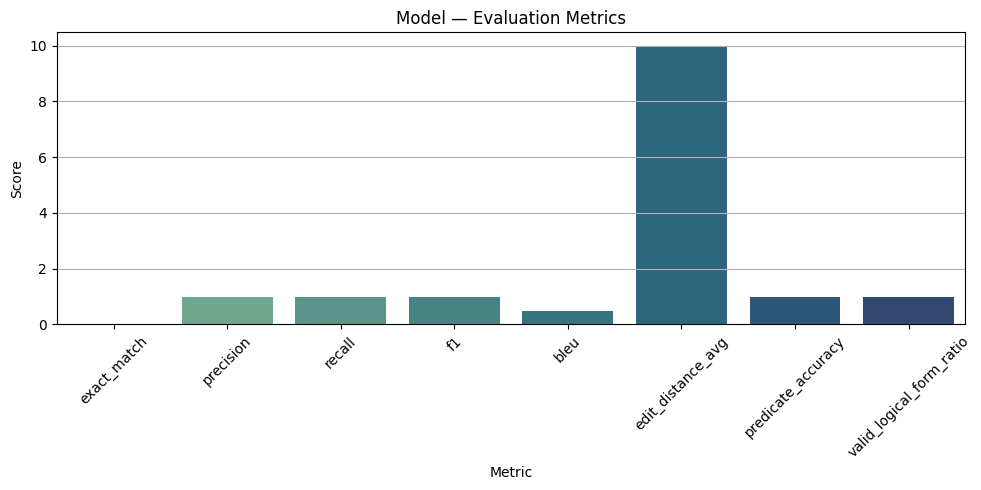

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(get_results_path(model_name, "test", enhancement))
plot_metrics_bar(get_results_path(model_name, "test", enhancement))

Predictions saved to: /notebooks/meta-semantic-research/predictions/kga/t5-small_gen_predictions.txt
Metrics saved to: /notebooks/meta-semantic-research/results/kga/t5-small_gen_metrics.csv
Gen Eval:
  exact_match: 0.0000
  precision: 0.9660
  recall: 0.8883
  f1: 0.9144
  bleu: 0.4114
  edit_distance_avg: 60.5026
  predicate_accuracy: 0.9189
  valid_logical_form_ratio: 0.9996


ValueError: Unknown format code 'f' for object of type 'str'

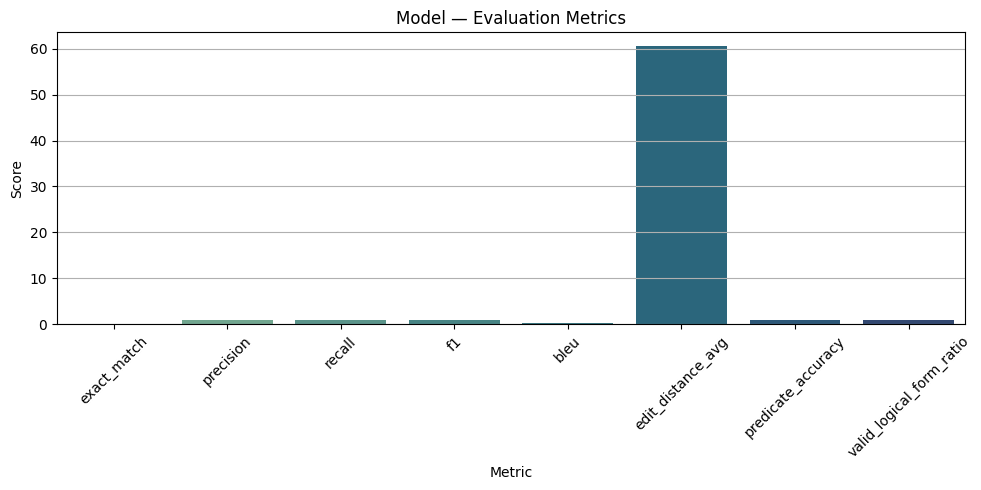

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(get_results_path(model_name, "gen", enhancement))
plot_metrics_bar(get_results_path(model_name, "gen", enhancement))

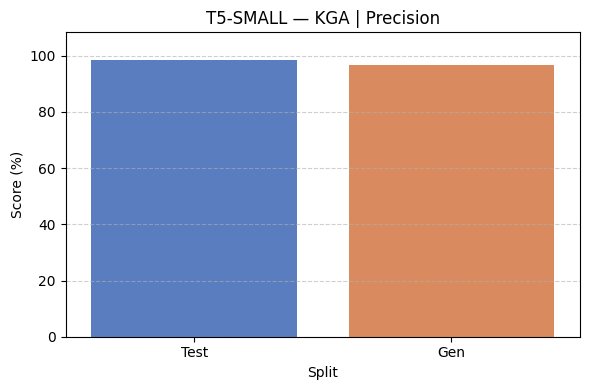

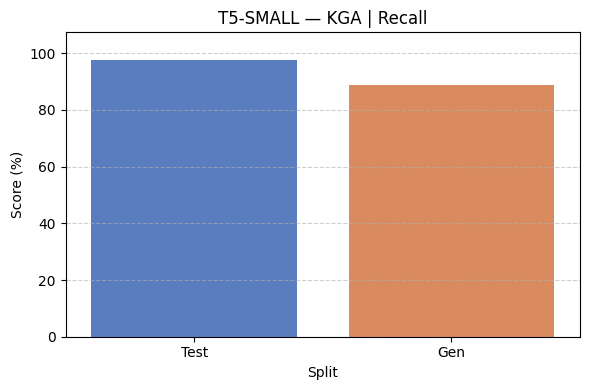

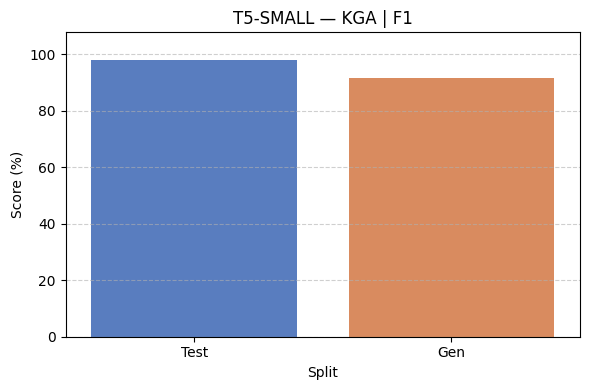

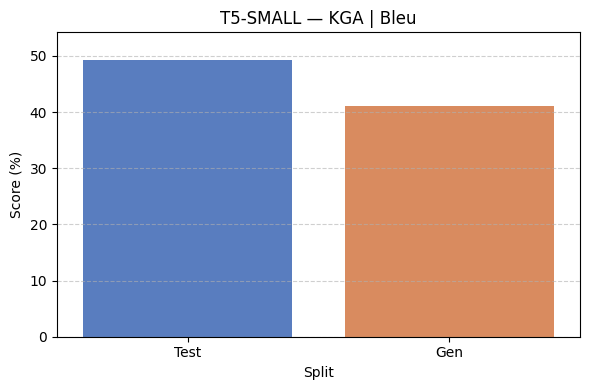

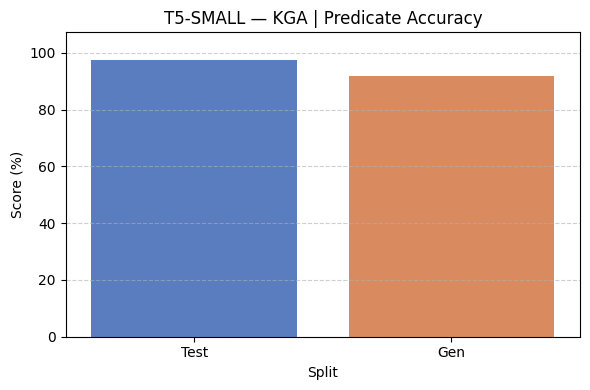

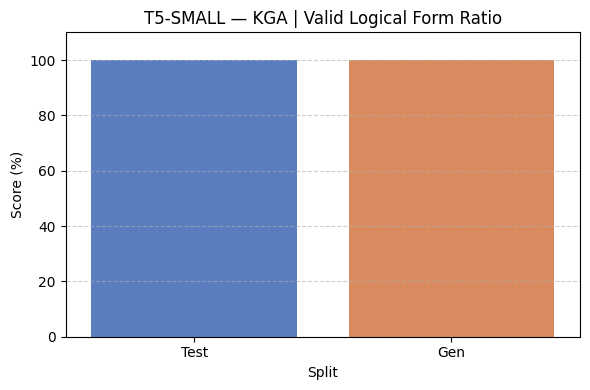

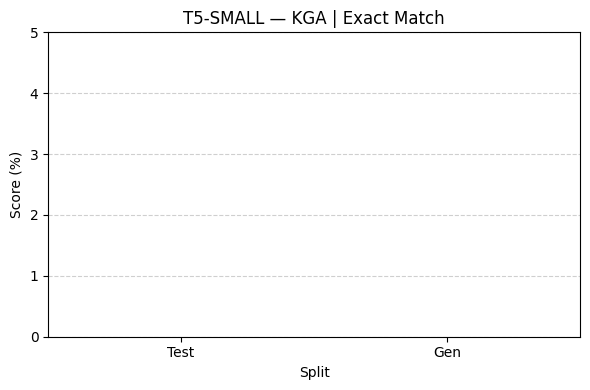

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)